# Brain Tumor Classification
# Complete Model Comparison

This notebook compares all implemented models:

1. CNN Baseline V1
2. CNN Baseline V2
3. ResNet18 Feature Extraction
4. ResNet18 Fine-Tuning

The goal is to evaluate architecture improvements and select the final model.

## IMPORTS

In [3]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

## PATHS

In [16]:
PROJECT_ROOT = Path("..")


RESULTS = {
    "CNN Baseline V1":
        PROJECT_ROOT / "experiments/cnn_baseline_v1/results/metrics.json",

    "CNN Baseline V2":
        PROJECT_ROOT / "experiments/cnn_baseline_v2/results/metrics.json",

    "ResNet18 Feature Extraction":
        PROJECT_ROOT /
        "experiments/resnet18_transfer_learning/results/metrics.json",

    "ResNet18 Fine-Tuned":
        PROJECT_ROOT /
        "experiments/resnet18_finetune/results/metrics.json",
}

## LOAD METRICS

In [17]:
models = {}

for name, path in RESULTS.items():

    print(name)

    with open(path) as f:
        models[name] = json.load(f)


print("\nAll models loaded ✓")

CNN Baseline V1
CNN Baseline V2
ResNet18 Feature Extraction
ResNet18 Fine-Tuned

All models loaded ✓


## COMPARISON DATAFRAME

In [18]:
comparison = pd.DataFrame(models).T

comparison

,accuracy,precision,recall,f1,loss
CNN Baseline V1,0.811162,0.827275,0.812054,0.811500,0.528271
CNN Baseline V2,0.964067,0.964289,0.967973,0.965532,0.127973
ResNet18 Feature Extraction,0.818043,0.820544,0.818925,0.818825,0.457776
ResNet18 Fine-Tuned,0.977829,0.980388,0.979988,0.980113,0.066127


## SORT BY ACCURACY

In [19]:
comparison.sort_values(
    "accuracy",
    ascending=False
)

,accuracy,precision,recall,f1,loss
ResNet18 Fine-Tuned,0.977829,0.980388,0.979988,0.980113,0.066127
CNN Baseline V2,0.964067,0.964289,0.967973,0.965532,0.127973
ResNet18 Feature Extraction,0.818043,0.820544,0.818925,0.818825,0.457776
CNN Baseline V1,0.811162,0.827275,0.812054,0.811500,0.528271


## SORT BY F1

In [20]:
comparison.sort_values(
    "f1",
    ascending=False
)

,accuracy,precision,recall,f1,loss
ResNet18 Fine-Tuned,0.977829,0.980388,0.979988,0.980113,0.066127
CNN Baseline V2,0.964067,0.964289,0.967973,0.965532,0.127973
ResNet18 Feature Extraction,0.818043,0.820544,0.818925,0.818825,0.457776
CNN Baseline V1,0.811162,0.827275,0.812054,0.811500,0.528271


## METRIC COMPARISON PLOT

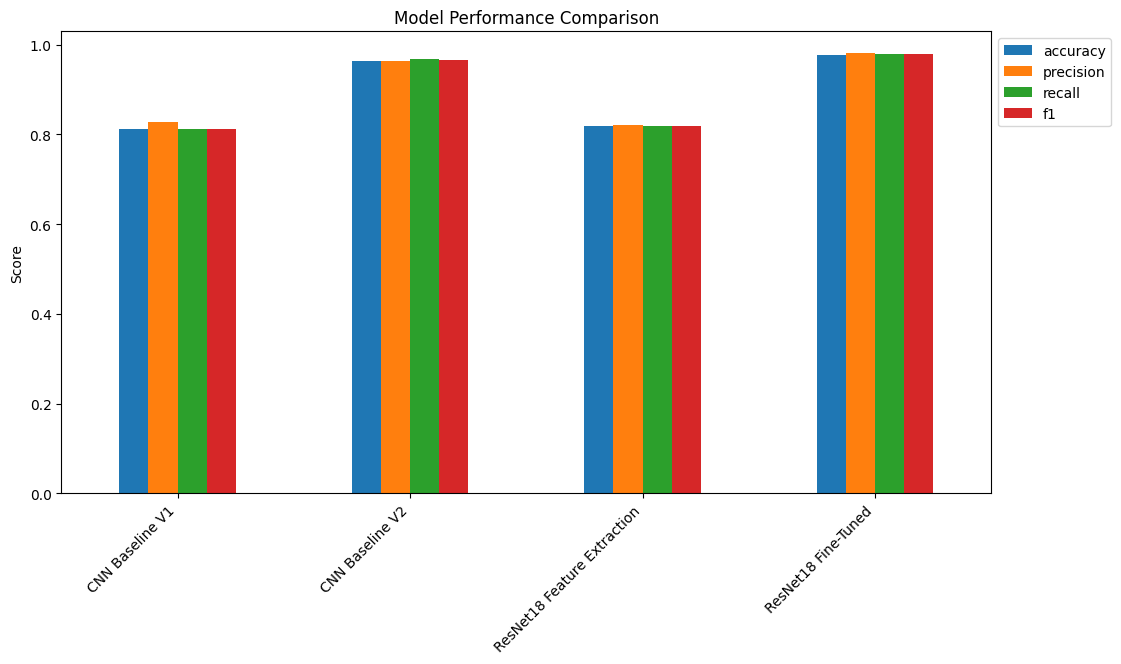

In [21]:
metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1"
]


comparison[metrics].plot(
    kind="bar",
    figsize=(12,6)
)

plt.ylabel(
    "Score"
)

plt.title(
    "Model Performance Comparison"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    bbox_to_anchor=(1,1)
)

plt.show()

## LOSS COMPARISON

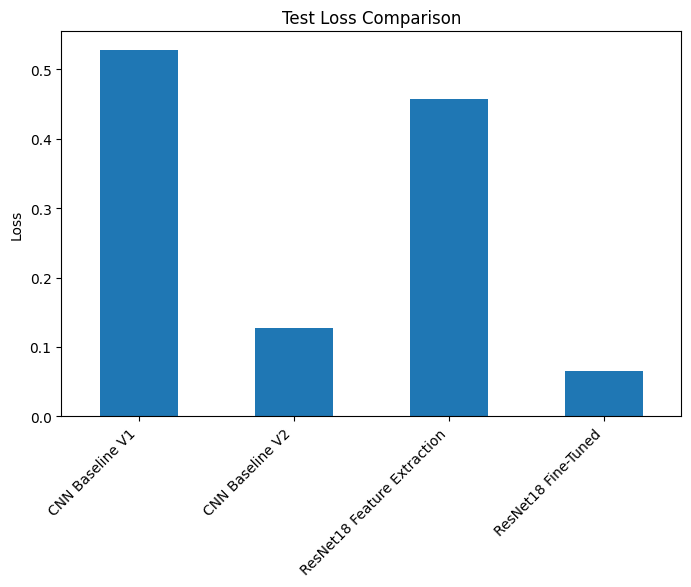

In [22]:
comparison["loss"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Test Loss Comparison"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.show()

## IMPROVEMENT FROM BASELINE V1

In [23]:
baseline = comparison.loc[
    "CNN Baseline V1"
]


final_model = comparison.loc[
    "ResNet18 Fine-Tuned"
]


improvement = pd.DataFrame({

    "absolute_change":
        final_model - baseline,

    "relative_percentage":
        ((final_model - baseline)
        /
        baseline)
        *100

})


improvement

,absolute_change,relative_percentage
accuracy,0.166667,20.546654
precision,0.153113,18.508156
recall,0.167934,20.680166
f1,0.168613,20.777897
loss,-0.462145,-87.482435


## RANKING

In [24]:
ranking = (
    comparison
    .sort_values(
        "accuracy",
        ascending=False
    )
)


ranking[[
    "accuracy",
    "f1",
    "loss"
]]

,accuracy,f1,loss
ResNet18 Fine-Tuned,0.977829,0.980113,0.066127
CNN Baseline V2,0.964067,0.965532,0.127973
ResNet18 Feature Extraction,0.818043,0.818825,0.457776
CNN Baseline V1,0.811162,0.811500,0.528271


# Final Conclusion

This notebook compared all major model variants developed in the project:

1. CNN Baseline V1
2. CNN Baseline V2
3. ResNet18 Feature Extraction
4. ResNet18 Fine-Tuned

---

## Overall Findings

The results show a clear progression in model quality as architectural and transfer learning improvements were introduced.

### CNN Baseline V1
The first baseline provided a useful reference point, but its performance was limited by relatively shallow feature extraction capacity. It achieved:

- Accuracy: 81.12%
- F1-score: 81.15%
- Loss: 0.528

This model established the initial benchmark but was not sufficient for high-confidence medical classification.

### CNN Baseline V2
The second CNN baseline significantly improved performance through a deeper architecture, stronger regularization, and improved training behavior. It achieved:

- Accuracy: 96.41%
- F1-score: 96.55%
- Loss: 0.128

This result shows that a well-designed custom CNN can perform very strongly on this dataset.

### ResNet18 Feature Extraction
Using ResNet18 only as a frozen feature extractor did not outperform the custom CNN baseline. It achieved:

- Accuracy: 81.80%
- F1-score: 81.88%
- Loss: 0.458

This confirms that ImageNet features alone are not sufficient for this MRI task without adaptation to the medical domain.

### ResNet18 Fine-Tuned
Fine-tuning the pretrained ResNet18 produced the best overall results:

- Accuracy: 97.78%
- F1-score: 98.01%
- Loss: 0.066

This was the strongest model in the project and clearly outperformed all other experiments.

---

## Interpretation

The results show three important points:

1. A simple CNN can be a useful starting point, but architecture depth and regularization matter greatly.
2. Frozen transfer learning is not always enough when the source domain and target domain differ significantly.
3. Fine-tuning pretrained layers is the most effective strategy for this medical imaging task.

The improvement from CNN Baseline V1 to ResNet18 Fine-Tuned was substantial:

- Accuracy improved by **16.67 percentage points**
- F1-score improved by **16.86 percentage points**
- Loss decreased by **87.48%**

---

## Final Model Selection

The final model selected for this project is:

**ResNet18 Fine-Tuned**

It provides the best balance of:

- accuracy
- precision
- recall
- F1-score
- low loss
- robust generalization

Although CNN Baseline V2 is also a very strong model, the fine-tuned ResNet18 remains the best overall choice for the final system.

---

## Project Outcome

This project demonstrates a full professional ML workflow:

- dataset exploration
- data validation
- baseline CNN modeling
- architectural improvement
- transfer learning
- fine tuning
- model comparison

The final results show that medical image classification benefits strongly from both careful baseline engineering and pretrained model adaptation.

The next step is model interpretability and inference.